In [ ]:
# Hipótesis Nula (H_0): Es la afirmación que se quiere contrastar , generalmente de "no efecto" o "no diferencia". Se asume como verdadera hasta
# que la evidencia muestral demuestre lo contrario.
# Hipótesis Alternativa (H_a): Es la afirmación que se busca probar. Puede ser unilateral (unidireccional) o bilateral (bidireccional).
# El Valor p y la Significancia Estadística

# Significancia Estadística: Mide la probabilidad de que los resultados de un experimento se deban únicamente al azar, en lugar de a un efecto
# real en la población.


# Nivel de Significancia (alpha): Es un umbral predefinido que determina cuándo rechazar la hipótesis nula. Representa la probabilidad máxima
# aceptable de cometer un error tipo I (rechazar

# H_0 cuando es verdadera). Los valores comunes para alpha son 0.05, 0.01 y 0.10.
# Valor-p: Cuantifica la fuerza de la evidencia en contra de la hipótesis nula. Es la probabilidad de obtener un resultado tan extremo o más extremo
# que el observado en los datos, asumiendo que H_0 es verdadera.

Errores Tipo I y Tipo II
Existen dos tipos de errores al realizar una prueba de hipótesis:

Error Tipo I: Ocurre al rechazar la hipótesis nula cuando es verdadera. La probabilidad de este error es

alpha. Un ejemplo práctico es concluir que un medicamento es efectivo cuando no lo es.

Error Tipo II: Ocurre al no rechazar la hipótesis nula cuando es falsa. La probabilidad de este error se denota con

beta. Un ejemplo es concluir que un medicamento no es efectivo cuando sí lo es.

Existe un compromiso entre ambos errores: reducir la probabilidad de uno aumenta la del otro. Sin embargo, aumentar el tamaño de la muestra puede reducir ambos.

Poder Estadístico (Power)
El poder estadístico de un experimento es la probabilidad de rechazar correctamente la hipótesis nula cuando esta es falsa. Se calcula como
1−beta. Un alto poder significa que el experimento tiene una mayor capacidad para detectar un efecto real si existe.


Los factores que afectan el poder son:

Tamaño de la muestra (n): Aumentar el tamaño de la muestra incrementa el poder al reducir la variabilidad.


Nivel de significancia (alpha): Un alpha más alto aumenta el poder, pero también el riesgo de un error tipo I.

Tamaño del efecto: Un efecto más grande es más fácil de detectar, lo que aumenta el poder.

Variabilidad de los datos: Una menor variabilidad mejora el poder.



¿Qué es el tamaño del efecto (o efecto estandarizado)?
En términos sencillos, el tamaño del efecto es una medida que cuantifica la magnitud de una diferencia o la fuerza de una relación entre variables. A diferencia del valor-p, que solo te dice si un resultado es estadísticamente significativo (es decir, si no es probable que se deba al azar), el tamaño del efecto te dice cuán grande o importante es ese resultado.

Imagina dos escenarios:

Escenario A: Un medicamento reduce el tiempo de recuperación en 5 segundos.

Escenario B: Un medicamento reduce el tiempo de recuperación en 5 horas.

En ambos casos, una prueba de hipótesis podría dar un valor-p muy bajo y concluir que el efecto es "estadísticamente significativo". Sin embargo, el tamaño del efecto es claramente mucho mayor en el Escenario B, lo que indica que el resultado es mucho más relevante y práctico.

Puntos Clave:
Mide la magnitud: No se enfoca en si una diferencia existe, sino en qué tan grande es.

Independiente del tamaño de la muestra: El tamaño del efecto es una medida estandarizada que no depende del tamaño de la muestra. Por ejemplo, la d de Cohen (una medida de tamaño del efecto común para la diferencia entre dos medias) es el "efecto estandarizado" que se menciona en el código. Se calcula como la diferencia de las medias dividida por la desviación estándar.

Importancia práctica: Es crucial para la interpretación de los resultados. Un resultado puede ser estadísticamente significativo pero tener un tamaño de efecto tan pequeño que carece de importancia práctica. Por ejemplo, un nuevo método de enseñanza que mejora las notas en 0.1% puede ser significativo si la muestra es grande, pero no es de gran utilidad en la vida real.

Relación con el Poder Estadístico
Como se menciona en el material, el tamaño del efecto tiene una relación directa y positiva con el poder estadístico.

Mayor tamaño del efecto = Mayor poder estadístico: Un efecto grande es más fácil de detectar en una muestra. Si la diferencia entre dos grupos es muy grande, necesitarás una muestra más pequeña para detectarla con el mismo nivel de confianza.

Menor tamaño del efecto = Menor poder estadístico: Si la diferencia es muy sutil, necesitarás una muestra mucho más grande para tener la suficiente "potencia" para detectarla y concluir que no es solo una fluctuación aleatoria.

El código de Python a continuación utiliza la función TTestIndPower de statsmodels, que requiere el parámetro effect_size. El valor efecto_estandarizado = 0.5 en ese ejemplo representa un tamaño del efecto moderado según las convenciones de Cohen.

En resumen, mientras que el valor-p te dice si un hallazgo es creíble (poco probable que sea por azar), el tamaño del efecto te dice si ese hallazgo es importante o relevante en la práctica. Ambos son necesarios para una interpretación completa y significativa de los resultados de una prueba de hipótesis.

In [ ]:
import numpy as np
from scipy.stats import norm
from statsmodels.stats.power import TTestPower

# Parámetros
mu_0 = 200      # Media bajo H0
mu_a = 190      # Media real alternativa
sigma = 15
n = 30
alpha = 0.05

# Paso 1: valor crítico bajo H0
z_alpha = norm.ppf(alpha)
x_critico = mu_0 + z_alpha * (sigma / np.sqrt(n))  # umbral de rechazo

# Paso 2: calcular la potencia como 1 - beta
# Beta: probabilidad de NO rechazar H0 cuando H1 es verdadera
beta = norm.cdf((x_critico - mu_a) / (sigma / np.sqrt(n)))
potencia = 1 - beta

print(f"Valor crítico de la muestra: {x_critico:.2f}")
print(f"Potencia de la prueba: {potencia:.3f}")

Valor crítico de la muestra: 195.50
Potencia de la prueba: 0.022


Resultados obtenidos
Valor crítico de la muestra: 195.50
→ Es el umbral debajo del cual se rechazaría H₀ (es decir, si la media muestral cae por debajo de 195.5, se concluye que el tratamiento reduce el colesterol).

Potencia de la prueba: 0.022
→ Esto significa que solo hay un 2.2% de probabilidad de detectar el verdadero efecto (μ = 190) con esta prueba.
→ O dicho de otro modo: β = 1 – 0.022 = 0.978 → muy alta probabilidad de cometer error tipo II (no detectar un efecto real).
¿Por qué la potencia es tan baja?
Diferencia entre medias: μ₀ = 200 vs. μₐ = 190 → aunque parece una diferencia de 10 unidades, es relativamente pequeña si la desviación estándar es 15 y el tamaño de muestra n = 30.

Tamaño de muestra pequeño: para un efecto pequeño a moderado, se necesita un tamaño de muestra mayor para alcanzar potencia ≥ 0.8 (nivel estándar deseado).

Conclusión aparente engañosa: aunque el valor p fue muy bajo en tu ejemplo anterior (rechazando H₀), eso dependió de un dato observado específico. Pero la potencia refleja la capacidad general de la prueba para detectar un efecto real antes de ver los datos.

¿Cómo aumentar la potencia?
Aumentar el tamaño de la muestra.

Disminuir la variabilidad (σ) si es posible.

Aumentar el nivel de significancia α (por ejemplo, de 0.05 a 0.1, aunque esto aumenta el riesgo de error tipo I).

Buscar un efecto más grande (mayor diferencia entre medias).

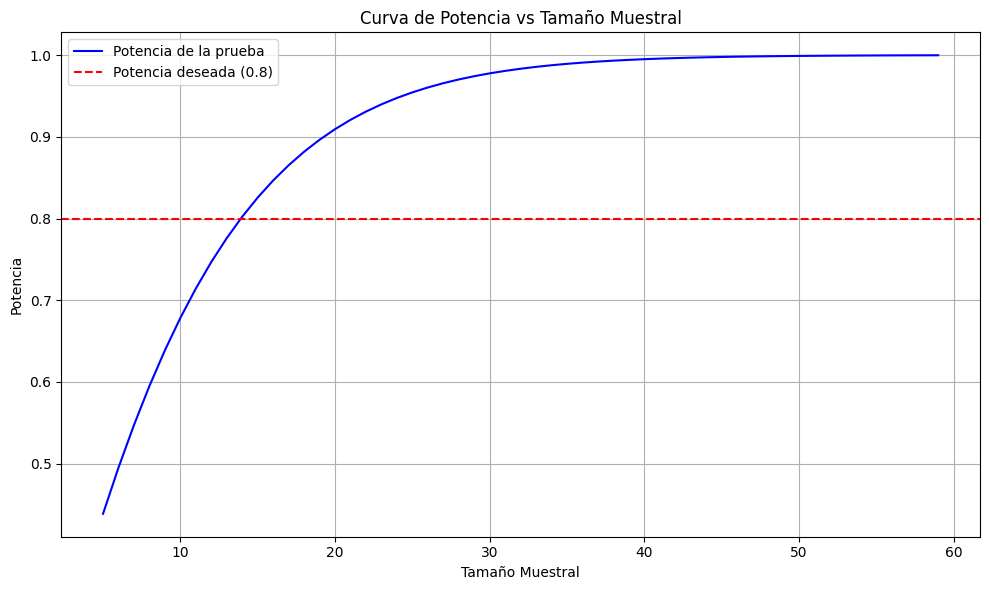

In [ ]:
# graficar la potencia de una prueba de hipótesis para la media en función del tamaño muestral.
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parámetros conocidos
mu_0 = 200      # Media bajo H0
mu_1 = 190      # Media bajo H1 (efecto real)
sigma = 15      # Desviación estándar
alpha = 0.05    # Nivel de significancia (5%)

# Crear una lista de tamaños muestrales a evaluar
n_values = np.arange(5, 60)

# Lista para guardar la potencia calculada
powers = []

for n in n_values:
    # Error estándar bajo H0 y H1
    se = sigma / np.sqrt(n)

    # Valor crítico z para cola izquierda
    z_critico = norm.ppf(alpha)

    # Punto de corte en la distribución de la muestra bajo H0
    x_critico = mu_0 + z_critico * se

    # Convertimos ese punto a una z en la distribución bajo H1
    z_bajo_H1 = (x_critico - mu_1) / se

    # Potencia = P(rechazar H0 | H1 es verdadera) = P(z < z_bajo_H1)
    potencia = norm.cdf(z_bajo_H1)
    powers.append(potencia)

# Gráfico
plt.figure(figsize=(10,6))
plt.plot(n_values, powers, label='Potencia de la prueba', color='blue')
plt.axhline(0.8, color='red', linestyle='--', label='Potencia deseada (0.8)')
plt.title("Curva de Potencia vs Tamaño Muestral")
plt.xlabel("Tamaño Muestral")
plt.ylabel("Potencia")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Ejemplo en Python para Calcular Poder Estadístico
# El documento proporciona un ejemplo para mostrar cómo la variabilidad y el tamaño de la muestra afectan el poder
# estadístico utilizando la biblioteca statsmodels.
from statsmodels.stats.power import TTestIndPower

# Parámetros iniciales
efecto_estandarizado = 0.5  # Tamaño del efecto
alpha = 0.05                # Nivel de significancia
n_inicial = 20
n_mejorado = 50
variabilidad_inicial = 1
variabilidad_mejorada = 0.8

# Función para calcular el poder
def calcular_poder(n, efecto, variabilidad):
    # Ajustar el tamaño del efecto
    efecto_ajustado = efecto / variabilidad
    power_analisis = TTestIndPower()
    poder = power_analisis.solve_power(
        effect_size=efecto_ajustado, nobs1=n, alpha=alpha, ratio=1.0, alternative='two-sided'
    )
    return poder
# n: El tamaño de la muestra para uno de los grupos (ya que la prueba t de dos muestras independientes compara dos grupos).
# efecto: El tamaño del efecto no estandarizado o el efecto esperado que se quiere detectar.
# variabilidad: La desviación estándar de los datos.

# efecto_ajustado = efecto / variabilidad: Esta es la línea clave que implementa el concepto de efecto estandarizado
# La función TTestIndPower de statsmodels espera un tamaño del efecto estandarizado como entrada.
# El tamaño del efecto estandarizado (efecto_ajustado) se calcula dividiendo la magnitud del efecto que esperas (efecto) por la desviación estándar
# de los datos (variabilidad).
# Esto es esencial porque permite comparar la magnitud del efecto de manera justa entre diferentes estudios, independientemente de las unidades de
# medida originales de los datos. Si el efecto es grande en comparación con la variabilidad de los datos, el efecto_ajustado será grande, y viceversa.
# power_analisis = TTestIndPower()

# Esta línea crea una instancia de la clase TTestIndPower de la biblioteca statsmodels.

# TTestIndPower es una herramienta de análisis de poder específicamente diseñada para la prueba t de dos muestras independientes
 # (t-test for two independent samples), que se utiliza para comparar las medias de dos grupos.

# 5. poder = power_analisis.solve_power(...)
# Esta línea es donde se realiza el cálculo real del poder estadístico.
# El método solve_power de la instancia TTestIndPower es una función versátil que puede resolver para cualquiera de las variables del
# análisis de poder (effect_size, nobs1, alpha, power) si se le dan los demás. En este caso, le estamos pidiendo que calcule el power.

# Los argumentos que se le pasan son:
# effect_size=efecto_ajustado: El tamaño del efecto estandarizado que acabamos de calcular.

# nobs1=n: El número de observaciones en el primer grupo.
# alpha=alpha: El nivel de significancia (por ejemplo, 0.05). Este valor se toma de una variable global definida fuera de la función.

# ratio=1.0: Indica que la proporción de tamaños de muestra entre los dos grupos es 1:1 (es decir, el tamaño del segundo grupo, nobs2,
# es igual a nobs1).
# alternative='two-sided': Especifica que la prueba de hipótesis es bilateral (de dos colas), lo que significa que estamos probando si
# las medias son diferentes, sin especificar si una es mayor o menor que la otra.

# 6. return poder
# La función devuelve el valor del poder estadístico calculado, que es un número entre 0 y 1.

# Calculamos el poder con el diseño inicial
poder_inicial = calcular_poder(n_inicial, efecto_estandarizado, variabilidad_inicial)
print(f"Poder con diseño inicial (n={n_inicial}, variabilidad={variabilidad_inicial}): {poder_inicial:.2f}")

# Calculamos el poder al mejorar el tamaño de la muestra
poder_mejorado_n = calcular_poder(n_mejorado, efecto_estandarizado, variabilidad_inicial)
print(f"Poder al mejorar la muestra (n={n_mejorado}): {poder_mejorado_n:.2f}")

# Calculamos el poder al mejorar la variabilidad
poder_mejorado_var = calcular_poder(n_inicial, efecto_estandarizado, variabilidad_mejorada)
print(f"Poder al mejorar la variabilidad (n={n_inicial}, variabilidad={variabilidad_mejorada}): {poder_mejorado_var:.2f}")

Poder con diseño inicial (n=20, variabilidad=1): 0.34
Poder al mejorar la muestra (n=50): 0.70
Poder al mejorar la variabilidad (n=20, variabilidad=0.8): 0.49


In [ ]:
import numpy as np
from scipy.stats import ttest_ind

# -----------------------------------------------
# Parámetros para la simulación
# -----------------------------------------------
# Tamaño del efecto estandarizado (d de Cohen): (media_grupo2 - media_grupo1) / sigma
efecto_estandarizado = 0.5

# Nivel de significancia (alfa)
alpha = 0.05

# Tamaño de la muestra por grupo (n)
n = 20

# Media del Grupo 1 (Control)
media_grupo1 = 0

# Desviación estándar de ambos grupos (se asume igual)
sigma = 1

# Número de simulaciones a realizar
n_simulaciones = 10000

# -----------------------------------------------
# Cálculo de la media del Grupo 2 a partir del tamaño del efecto
# -----------------------------------------------
# efecto_estandarizado = (media_grupo2 - media_grupo1) / sigma
# Por lo tanto: media_grupo2 = efecto_estandarizado * sigma + media_grupo1
media_grupo2 = efecto_estandarizado * sigma + media_grupo1

# -----------------------------------------------
# Realizar la simulación
# -----------------------------------------------
p_valores = []

for _ in range(n_simulaciones):
    # Generar datos aleatorios para el Grupo 1
    # np.random.normal(loc=media, scale=desviacion_estandar, size=tamano)
    datos_grupo1 = np.random.normal(loc=media_grupo1, scale=sigma, size=n)

    # Generar datos aleatorios para el Grupo 2
    datos_grupo2 = np.random.normal(loc=media_grupo2, scale=sigma, size=n)

    # Realizar la prueba t de Student para dos muestras independientes
    estadistico_t, p_valor = ttest_ind(datos_grupo1, datos_grupo2)

    # Almacenar el valor-p
    p_valores.append(p_valor)

# -----------------------------------------------
# Calcular el poder estadístico
# -----------------------------------------------
# Contar el número de veces que el p-valor es menor que alpha
poder_calculado = np.mean(np.array(p_valores) < alpha)

# -----------------------------------------------
# Imprimir los resultados
# -----------------------------------------------
print(f"Parámetros de la simulación:")
print(f"  - Tamaño del efecto: {efecto_estandarizado}")
print(f"  - Nivel de significancia (alpha): {alpha}")
print(f"  - Tamaño de la muestra por grupo (n): {n}")
print(f"  - Número de simulaciones: {n_simulaciones}")
print("-" * 30)
print(f"Poder estadístico (calculado por simulación): {poder_calculado:.4f}")
print(f"Poder esperado según statsmodels (aprox.): 0.34")

Parámetros de la simulación:
  - Tamaño del efecto: 0.5
  - Nivel de significancia (alpha): 0.05
  - Tamaño de la muestra por grupo (n): 20
  - Número de simulaciones: 10000
------------------------------
Poder estadístico (calculado por simulación): 0.3398
Poder esperado según statsmodels (aprox.): 0.34


In [ ]:
# Ejemplo 1: Prueba de hipótesis sobre una media poblacional (Z-test)
# Supongamos:
# μ₀ = 50 (hipótesis nula)
# X̄ = 52 (media muestral)
# σ = 10 (desviación estándar conocida)
# n = 36 (tamaño de muestra)
# α = 0.05
import scipy.stats as stats
import numpy as np

# Parámetros
mu_0 = 50      # H0: media poblacional
x_bar = 52     # media muestral
sigma = 10     # desviación estándar
n = 36         # tamaño de la muestra
alpha = 0.05   # nivel de significancia

# Estadístico Z
z = (x_bar - mu_0) / (sigma / np.sqrt(n))
p_value = 2 * (1 - stats.norm.cdf(abs(z)))  # prueba bilateral

# Resultados
print(f"Estadístico Z: {z:.3f}")
print(f"Valor p: {p_value:.4f}")

# Decisión
if p_value < alpha:
    print("Rechazamos H0: hay evidencia significativa.")
else:
    print("No rechazamos H0: no hay suficiente evidencia.")

Estadístico Z: 1.200
Valor p: 0.2301
No rechazamos H0: no hay suficiente evidencia.


In [ ]:
# Ejemplo 2: Prueba sobre una proporción
# Supongamos:
# p₀ = 0.5
# p̂ = 0.55
# n = 100
# α = 0.05
p_hat = 0.55
p_0 = 0.5
n = 100

# Estadístico Z
z = (p_hat - p_0) / np.sqrt(p_0 * (1 - p_0) / n)
p_value = 2 * (1 - stats.norm.cdf(abs(z)))

print(f"Estadístico Z: {z:.3f}")
print(f"Valor p: {p_value:.4f}")

if p_value < alpha:
    print("Rechazamos H0: la proporción poblacional es diferente de 0.5.")
else:
    print("No rechazamos H0: no hay evidencia para afirmar diferencia.")

Estadístico Z: 1.000
Valor p: 0.3173
No rechazamos H0: no hay evidencia para afirmar diferencia.


In [ ]:
# Errores en pruebas de hipótesis
# Error tipo I (α): Rechazar H₀ siendo verdadera.
# Error tipo II (β): No rechazar H₀ siendo falsa.
# Poder estadístico: 1 − β → probabilidad de detectar un efecto real.
# Diseño experimental
# Objetivo claro (ej: “¿Mejora el nuevo tratamiento?”)
# Variables: independientes (tratamiento), dependientes (resultado), controladas.
# Asignación aleatoria.
# Tamaño de muestra suficiente para buen poder estadístico.

In [ ]:
#  Ejemplo final: Cálculo de poder estadístico
from statsmodels.stats.power import TTestIndPower

power_analysis = TTestIndPower()
effect_size = 0.5   # tamaño del efecto estándar
alpha = 0.05
n = 50              # tamaño de muestra

power = power_analysis.power(effect_size=effect_size, nobs1=n, alpha=alpha, ratio=1.0, alternative='two-sided')
print(f"Poder estadístico: {power:.3f}")

Poder estadístico: 0.697


In [ ]:
import numpy as np
from scipy.stats import t
import matplotlib.pyplot as plt
# Parámetros de la prueba
mu_0 = 5.0      # Hipótesis nula
mu_1 = 5.5      # Hipótesis alternativa (media verdadera)
s = 1.28        # Desviación estándar muestral (estimador de sigma)
n = 30          # Tamaño muestral
alpha = 0.05    # Nivel de significancia

# Grados de libertad
df = n - 1

# Paso 1: Calcular valores críticos para prueba bilateral con t
t_crit = t.ppf(1 - alpha / 2, df)
x_crit_izq = mu_0 - t_crit * (s / np.sqrt(n))
x_crit_der = mu_0 + t_crit * (s / np.sqrt(n))

# Paso 2: Calcular β (error tipo II) y potencia
# Bajo H1, usamos mu_1 como media verdadera
t_beta_izq = (x_crit_izq - mu_1) / (s / np.sqrt(n))
t_beta_der = (x_crit_der - mu_1) / (s / np.sqrt(n))

beta = t.cdf(t_beta_der, df) - t.cdf(t_beta_izq, df)
potencia = 1 - beta

# Imprimir resultados
print(f"Valores críticos (bajo H0): {x_crit_izq:.2f}, {x_crit_der:.2f}")
print(f"Error Tipo II (β): {beta:.4f}")
print(f"Potencia de la prueba (1 - β): {potencia:.4f}")

Valores críticos (bajo H0): 4.52, 5.48
Error Tipo II (β): 0.4626
Potencia de la prueba (1 - β): 0.5374
